In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Sleep_Health_and_Lifestyle_Dataset.csv")  # path from notebooks folder

# Show first few rows
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
# Check missing values in the two columns for H1
print(df.columns)


Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')


In [12]:
df

372

In [3]:
# Keep only relevant columns and drop rows with missing values
df_h1 = df[['Daily Steps', 'Quality of Sleep']].dropna()

# Quick look
df_h1.head()


,Daily Steps,Quality of Sleep
0,4200,6
1,10000,6
2,10000,6
3,3000,4
4,3000,4


In [13]:
df_h1

,Daily Steps,Quality of Sleep,Active
0,4200,6,False
1,10000,6,True
2,10000,6,True
3,3000,4,False
4,3000,4,False
...,...,...,...
369,7000,9,True
370,7000,9,True
371,7000,9,True
372,7000,9,True


In [4]:
# Create binary Active column
threshold = 7000
df_h1['Active'] = df_h1['Daily Steps'] >= threshold

# Check group sizes
print(df_h1['Active'].value_counts())


Active
True     207
False    167
Name: count, dtype: int64


In [5]:
# Summary statistics for Sleep Quality by Active status
df_h1.groupby('Active')['Quality of Sleep'].describe()

,count,mean,std,min,25%,50%,75%,max
Active,,,,,,,,
False,167.0,6.922156,1.321709,4.0,6.0,7.0,8.0,9.0
True,207.0,7.628019,0.981275,6.0,7.0,8.0,8.0,9.0


In [15]:
# Separate Sleep Quality for Active and Inactive groups
active_sleep = df_h1[df_h1['Active'] == True]['Quality of Sleep']
inactive_sleep = df_h1[df_h1['Active'] == False]['Quality of Sleep']

In [16]:
# Variances
var_active = active_sleep.var()
var_inactive = inactive_sleep.var()

F = var_active / var_inactive
print("F-test statistic:", F)

F-test statistic: 0.5512002484514329


In [17]:
from scipy.stats import ttest_ind

# Two-sample t-test (equal variances)
t_stat, p_val = ttest_ind(active_sleep, inactive_sleep, equal_var=True)
print("t-statistic:", t_stat)
print("p-value:", p_val)


t-statistic: 5.922925705961272
p-value: 7.202381438291234e-09


In [18]:
n1 = len(active_sleep)
n2 = len(inactive_sleep)
df = n1 + n2 - 2
df

372

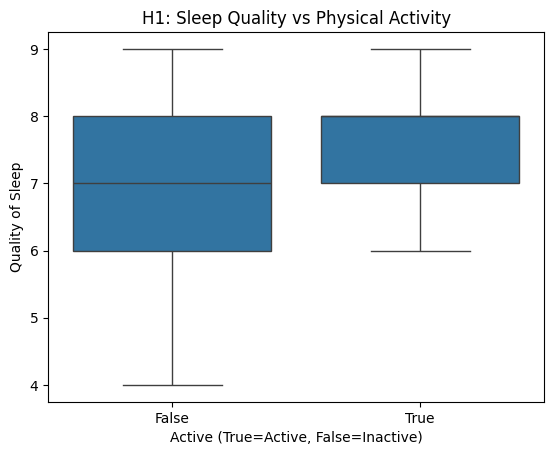

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Active', y='Quality of Sleep', data=df_h1)
plt.xlabel("Active (True=Active, False=Inactive)")
plt.ylabel("Quality of Sleep")
plt.title("H1: Sleep Quality vs Physical Activity")
plt.show()

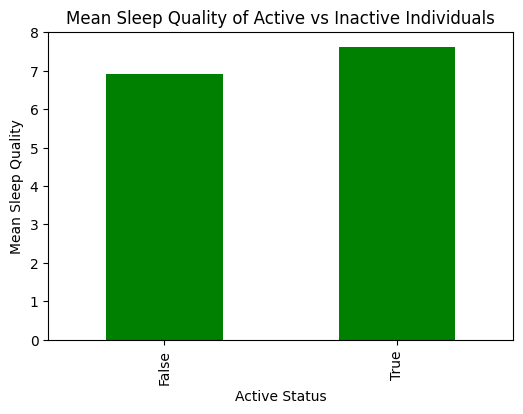

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df_h1.groupby('Active')['Quality of Sleep'].mean().plot(kind='bar',color = "green")
plt.xlabel("Active Status")
plt.ylabel("Mean Sleep Quality")
plt.title("Mean Sleep Quality of Active vs Inactive Individuals")
plt.show()